In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.cluster import MeanShift
import random

In [2]:
np.random.seed(84)
random.seed(84)

In [3]:
pd.options.display.max_seq_items = 2000

In [4]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

X = data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

data['cluster'] = clustering.labels_

cluster_set = list(set(data.cluster))

index_clusters = data.groupby('cluster').T_R_C.mean().sort_values().index.values

val_clusters = index_clusters[[2, 4]]
test_clusters = index_clusters[[6]]
train_clusters = index_clusters[[0,1,3,5]]

loc_validation = data['cluster'].isin(val_clusters)
loc_training =  data['cluster'].isin(train_clusters)
loc_test = data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

data['training'] = loc_training

In [5]:
data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
6    253.500000
5    262.545455
4    271.000000
Name: T_R_C, dtype: float64

In [6]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       'F_C31': 31, 'F_C32': 32,
       'F_C33': 33, 'F_C34': 34,
       'F_C35': 35, 
       'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       'F_Olef_C16': 16, 'F_Olef_C17': 17, 
       'F_Olef_C18': 18, 
}

In [7]:
Fn_exp_parafins = data[list(Ns_parafins.keys())]

Fn_exp_olefins = data[list(Ns_olefins.keys())]

Fn_exp_parafins.columns = Ns_parafins.values()
Fn_exp_parafins.columns = Fn_exp_parafins.columns.astype('int32')

Fn_exp_olefins.columns = Ns_olefins.values()
Fn_exp_olefins.columns = Fn_exp_olefins.columns.astype('int32')

In [8]:
Fn_exp = Fn_exp_parafins.copy()

In [9]:
for i in Ns_olefins.values():
    Fn_exp[i] = Fn_exp[i] + Fn_exp_olefins[i]

In [10]:
# drop rows with zeros otherwise it won't fit
# Fn_exp = Fn_exp[(Fn_exp != 0).all(axis=1)]
Fn_exp = Fn_exp.astype('float')

In [11]:
data = data.loc[Fn_exp.index].copy()

In [12]:
upsilon = Fn_exp_parafins / Fn_exp
# upsilon = upsilon[(upsilon.notna()).all(axis=1)]

In [13]:
upsilon['T_R_K'] = data.T_R_K
upsilon['T_R_C'] = data.T_R_C
upsilon['H2_CO'] = data.H2_CO
upsilon['P_abs_Pa'] = data.P_abs_Pa
upsilon['training'] = data.training
upsilon['index'] = data.index

In [14]:
upsilon = upsilon.melt(id_vars = ['T_R_K', 
                                  'T_R_C', 
                                  'H2_CO', 
                                  'P_abs_Pa', 
                                  'training', 'index'], var_name = 'n', value_name = 'upsilon_exp')

In [15]:
upsilon[['T_R_K', 'T_R_C', 'H2_CO', 
         'P_abs_Pa', 'upsilon_exp']] = upsilon[['T_R_K', 'T_R_C', 'H2_CO', 
                                                'P_abs_Pa', 'upsilon_exp']].astype('float')
upsilon.n = upsilon.n.astype('int32')
upsilon['index'] = upsilon['index'].astype('int32')

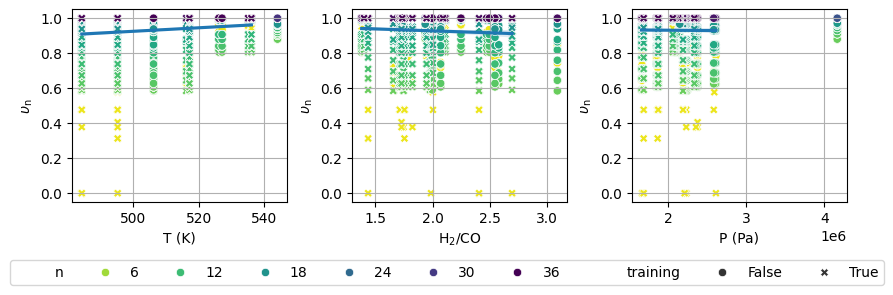

In [16]:
fig, ax = plt.subplots(1,3,figsize=(10,2.5))
plt.subplots_adjust(wspace=0.3)

sns.scatterplot(x='T_R_K', y='upsilon_exp', 
                data=upsilon, ax = ax[0], hue = 'n', style = 'training', palette = 'viridis_r')
sns.regplot(x='T_R_K', y='upsilon_exp', data=upsilon[upsilon.training], ax = ax[0], marker = '')
ax[0].legend().remove()
ax[0].set_ylabel(r'$\upsilon_\mathrm{n}$')
ax[0].set_xlabel('T (K)')
ax[0].grid('both')
ax[0].set_ylim(-0.05, 1.05)

sns.scatterplot(x='H2_CO', y='upsilon_exp', 
                data=upsilon, ax = ax[1], hue = 'n', style = 'training', palette = 'viridis_r')
sns.regplot(x='H2_CO', y='upsilon_exp', data=upsilon[upsilon.training], ax = ax[1], marker = "")
ax[1].legend().remove()
ax[1].set_ylabel(r'$\upsilon_\mathrm{n}$')
ax[1].set_xlabel(r'$\mathrm{H_2 / CO}$')
ax[1].grid('both')
ax[1].set_ylim(-0.05, 1.05)

sns.scatterplot(x='P_abs_Pa', y='upsilon_exp', data=upsilon, ax = ax[2], 
                hue = 'n', style = 'training', palette = 'viridis_r')
sns.regplot(x='P_abs_Pa', y='upsilon_exp', data=upsilon[upsilon.training], ax = ax[2], marker = "")
ax[2].legend().remove()
ax[2].set_ylabel(r'$\upsilon_\mathrm{n}$')
ax[2].set_xlabel('P (Pa)')
ax[2].grid('both')
ax[2].set_ylim(-0.05, 1.05)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.25), # Adjust 0.92 to move it up or down
           ncol=10, 
           frameon=True)

fig_name = 'upsilon_T_P_H2_CO.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()

In [17]:
def calc_upsilon(beta, n, T):
    exponent = beta[0] + beta[1] * n + beta[2] * T + beta[3] * ( n == 2 )
    return 1 / ( 1 + ( 1 - ( ( n == 1 ) | ( n == 3 ) ) ) * np.exp( - exponent ) )

In [18]:
def residuals(beta, n, T):
    return upsilon.loc[upsilon.training].upsilon_exp.values - calc_upsilon(beta, n, T)

In [19]:
def SSR(beta, n, T):
    return ( residuals(beta, n, T) ** 2 ).sum()

In [20]:
beta0 = np.array([-13.56,   0.3305,   0.02179,   2.291])

n = upsilon.loc[upsilon.training].n.values
T = upsilon.loc[upsilon.training].T_R_K.values

sol = minimize(SSR, beta0,
             method='Nelder-Mead',
             bounds=None, 
             args = (n, T),
             options = {'maxfev': 3000},
             )

sol

In [21]:
upsilon['upsilon_model'] = calc_upsilon(beta0, upsilon.n, upsilon.T_R_K)

In [22]:
X = upsilon[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

upsilon['cluster_T'] = clustering.labels_

In [23]:
upsilon.groupby(['cluster_T'])['T_R_C'].mean().sort_values()

cluster_T
3    211.000000
0    222.000000
2    233.000000
1    243.687500
6    253.500000
5    262.545455
4    271.000000
Name: T_R_C, dtype: float64

In [24]:
upsilon['data_set'] = 'training'
upsilon.loc[upsilon['index'].isin(idx_test) ,'data_set'] = 'test'
upsilon.loc[upsilon['index'].isin(idx_validation) ,'data_set'] = 'validation'

In [25]:
upsilon_mean = upsilon.groupby(['cluster_T', 'n', 'data_set']).mean()
upsilon_mean['T_R_C'] = upsilon_mean['T_R_C'].round(0)

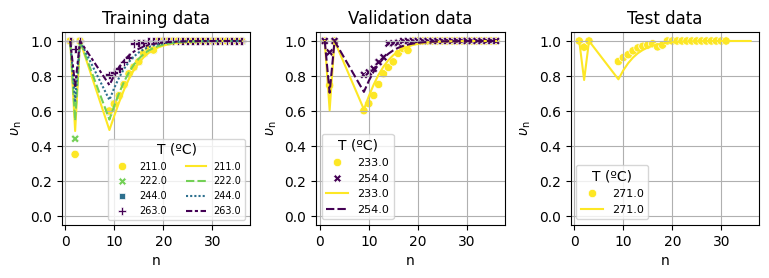

In [26]:
fig, ax = plt.subplots(1,3,figsize=(9, 2.5))
plt.subplots_adjust(wspace=0.35)

scale = 'linear'

sns.scatterplot(x='n', y='upsilon_exp',
             data=upsilon_mean.loc[(slice(None), slice(None), 'training')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[0])

sns.lineplot(x='n', y='upsilon_model',
             data=upsilon_mean.loc[(slice(None), slice(None), 'training')], ax = ax[0],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$\upsilon_\mathrm{n}$')
ax[0].set_yscale(scale)
ax[0].set_title('Training data')
ax[0].set_ylim(-0.05, 1.05)

sns.scatterplot(x='n', y='upsilon_exp',
             data=upsilon_mean.loc[(slice(None), slice(None), 'validation')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='upsilon_model',
             data=upsilon_mean.loc[(slice(None), slice(None), 'validation')], ax = ax[1],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$\upsilon_\mathrm{n}$')
ax[1].set_yscale(scale)
ax[1].set_title('Validation data')
ax[1].set_ylim(-0.05, 1.05)

sns.scatterplot(x='n', y='upsilon_exp',
             data=upsilon_mean.loc[(slice(None), slice(None), 'test')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='upsilon_model',
             data=upsilon_mean.loc[(slice(None), slice(None), 'test')], ax = ax[2], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$\upsilon_\mathrm{n}$')
ax[2].set_yscale(scale)
ax[2].set_title('Test data')
ax[2].set_ylim(-0.05, 1.05)

fig_name = 'upsilon_n.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()

sol.x

np.save('params_upsilon.npy', sol.x)